# 03 - Mapping majors to 14 interest-based model clusters

**Purpose.** The model must predict a *category of study*, not a free-text major. In the cleaned data there are 5,551 different major strings, so we first map each string to one of **14 model clusters**.
This notebook only builds and checks the mapping. **No train/test split is made and no model is trained.**

**Inputs (read-only):** `processed/riasec_clean.csv`, `processed/major_counts.csv`, and the three config files in `config/` that hold every mapping decision.
**Outputs:** `processed/riasec_labelled.csv`, `processed/major_mapping_full.csv`, and two charts in `notes/figures/`.

## 0. Setup
We load the cleaned data and the config files. Seed 42 is set (nothing below is random). We also take a checksum of the input file so we can prove at the end that it was not modified.

In [1]:
from pathlib import Path
import re, random, hashlib
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import Image, display
random.seed(42); np.random.seed(42)
pd.set_option("display.width", 220); pd.set_option("display.max_rows", 400); pd.set_option("display.max_colwidth", 90)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CFG, PROC, FIG = ROOT / "config", ROOT / "processed", ROOT / "notes" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
sha_before = hashlib.sha256((PROC / "riasec_clean.csv").read_bytes()).hexdigest()

clean = pd.read_csv(PROC / "riasec_clean.csv", keep_default_na=False)
counts = pd.read_csv(PROC / "major_counts.csv", keep_default_na=False)
clusters = pd.read_csv(CFG / "model_clusters.csv")
manual_df = pd.read_csv(CFG / "major_to_cluster.csv", keep_default_na=False)
rules = pd.read_csv(CFG / "keyword_rules.csv", keep_default_na=False)
ITEMS = [f"{l}{i}" for l in "RIASEC" for i in range(1, 9)]
SC = [f"{l}_score" for l in "RIASEC"]
print("clean rows:", len(clean), "| distinct majors:", len(counts), "| manual rows:", len(manual_df), "| keyword rules:", len(rules))

clean rows: 41947 | distinct majors: 5551 | manual rows: 300 | keyword rules: 35


## 1. Why 14 model clusters and not the 20 KUCCPS clusters

**KUCCPS groups degrees by KCSE entry requirements, not by interests.** For example, KUCCPS cluster 3 combines psychology, journalism and fine arts, which have very different RIASEC profiles.
A model that learns RIASEC interest profiles needs classes whose members share an interest pattern, so we use **14 interest-based model clusters**, and keep a separate table that maps each model cluster back to its KUCCPS clusters for the later eligibility step.
Small KUCCPS clusters (French/German, geosciences, sport science and others) are merged into larger model clusters because they have too few rows to learn from.

In [2]:
print(clusters.to_string(index=False))

 cluster_id                                   name kuccps_clusters                                                                                                       description
          1               Psychology & Counselling               3                           Psychology and counselling degrees; people-focused, investigative, helping professions.
          2       Social Sciences & Public Affairs           3, 14 Sociology, politics, social work, criminal justice, anthropology, international relations, public administration.
          3                  Media & Communication               3                                         Communication, journalism, advertising, public relations, film and media.
          4          Creative Arts, Design & Music       3, 11, 18                            Art, design, music, theatre, dance, photography and other creative-production degrees.
          5     Languages, Literature & Humanities   14, 17, 20, 3    English, history, philoso

## 2. How the mapping works (three layers, in this order)

1. **Hand-mapped table** (`config/major_to_cluster.csv`): the 300 most common normalised majors, about 81% of rows, each with a `confident` yes/no flag and a note. A hand-mapped string can map to a cluster or be deliberately left unmapped.
2. **Keyword rules** (`config/keyword_rules.csv`, in priority order) for the long tail. The rule that fires is recorded (`keyword:<rule>`). Within the rules:
   * *vague* rules drop strings that are too broad ("general studies", "liberal arts", "arts", "ba", "aa"...);
   * *phrase* rules are whole-string names that contain "and" in the name itself, so they are tried before the multi-major split ("computer science and engineering" goes to 9, "industrial and organizational psychology" and "I/O psychology" to 1);
   * *override* rules are other specific phrases that are tried first (e.g. "educational psychology" goes to 14, "law enforcement" to 2, "veterinary" to 12, and subject-teaching degrees such as "music education" to 14, because in Kenya they are B.Ed programmes, KUCCPS cluster 19);
   * *multi-major strings* (containing `,` `/` `&` `+` `;` or "and") are split, and mapped **only if every part lands in the same cluster**;
   * the *strong* rule "engineer" outranks the general rules (so "biomedical engineering" goes to 10, not 11);
   * *general* rules are keywords such as "nurs" or "psych". **If one string matches general rules from two different clusters** (e.g. "psychology education") it is dropped as `UNMAPPED_CONFLICT`, because a wrong label is worse than a missing one.
3. **Everything else** is unmapped and dropped, with a recorded reason: `UNMAPPED_VAGUE`, `UNMAPPED_MULTI`, `UNMAPPED_CONFLICT`, `UNMAPPED_AMBIGUOUS` (hand-mapped strings I could not place without guessing) or `UNMAPPED_NO_RULE`.

In [3]:
# Load the config into lookups and check it is internally consistent.
valid_ids = set(clusters["cluster_id"])
manual = {}
for r in manual_df.itertuples():
    if r.cluster_id == "":
        manual[r.major_norm] = (None, r.note.split(":")[0])             # (no cluster, UNMAPPED_* reason)
    else:
        manual[r.major_norm] = (int(r.cluster_id), "")
assert all(c in valid_ids for c, _ in manual.values() if c is not None)
rules["rx"] = rules["pattern"].map(re.compile)
assert all(int(c) in valid_ids for c in rules.loc[rules.cluster_id != "", "cluster_id"])
by_kind = {k: list(g.itertuples()) for k, g in rules.groupby("kind")}
print({k: len(v) for k, v in by_kind.items()}, "| manual strings:", len(manual))
print("manual 'confident = no':", int((manual_df.confident == "n").sum()))

{'general': 15, 'override': 16, 'phrase': 2, 'strong': 1, 'vague': 1} | manual strings: 300
manual 'confident = no': 52


### 2a. The mapping function
First the same normalisation used in step 02 (lowercase, drop apostrophes, other punctuation becomes a space). Then `assign()` applies the layers above to one major.

In [4]:
def norm_major(s):
    s = s.lower().replace("'", "").replace("’", "")
    s = re.sub(r"[^\w\s]", " ", s).replace("_", " ")
    return re.sub(r"\s+", " ", s).strip()

def first_match(kind, text):
    for r in by_kind.get(kind, []):
        if r.rx.search(text): return r
    return None

def map_text(text):
    """override -> strong -> general. Returns (cluster, rule_id) or (None, reason)."""
    r = first_match("phrase", text) or first_match("override", text) or first_match("strong", text)
    if r: return int(r.cluster_id), r.rule_id
    hits = [h for h in by_kind["general"] if h.rx.search(text)]
    if not hits: return None, "UNMAPPED_NO_RULE"
    if len({int(h.cluster_id) for h in hits}) > 1: return None, "UNMAPPED_CONFLICT"
    return int(hits[0].cluster_id), hits[0].rule_id

def assign(raw_major, norm, use_manual=True):
    """Returns (cluster_id or None, method, unmapped_reason)."""
    if use_manual and norm in manual:
        c, reason = manual[norm]
        return (c, "manual", "") if c is not None else (None, "manual", reason)
    if first_match("vague", norm): return None, "unmapped", "UNMAPPED_VAGUE"
    r = first_match("phrase", norm)                        # whole-string phrases that contain "and" in their own name
    if r: return int(r.cluster_id), f"keyword:{r.rule_id}", ""
    parts = [p for p in re.split(r"[,/&+;]|\band\b", raw_major, flags=re.I) if norm_major(p)]
    if len(parts) > 1:                                      # looks like several fields: map each part
        got = []
        for p in parts:
            pn = norm_major(p)
            if use_manual and pn in manual:
                c, _ = manual[pn]; got.append((c, "manual"))
            elif first_match("vague", pn): got.append((None, "vague"))
            else: got.append(map_text(pn))
        if all(c is not None for c, _ in got):
            if len({c for c, _ in got}) > 1: return None, "unmapped:different-clusters", "UNMAPPED_MULTI"
            ids = "+".join(dict.fromkeys(rid for _, rid in got))
            return got[0][0], f"keyword-multi:{ids}", ""
        # a part could not be mapped: the "and" may be part of ONE field's name
        # (e.g. "communication sciences and disorders"), so try the specific-phrase rules on the whole string
        r = first_match("override", norm)
        if r: return int(r.cluster_id), f"keyword:{r.rule_id}", ""
        return None, "unmapped:part-unmapped", "UNMAPPED_MULTI"
    c, rid = map_text(norm)
    return (c, f"keyword:{rid}", "") if c is not None else (None, "unmapped", rid)

### 2b. Unit tests: the rules you specified
Each row is a test case with the expected result. `use_manual=False` makes the *keyword engine alone* answer, to prove the rules (not just the hand table) respect your rulings.

In [5]:
tests = [  # (raw text, expected cluster or reason)
 ("Educational Psychology", 14), ("law enforcement", 2), ("Biomedical Engineering", 10), ("veterinary nursing", 12),
 ("Veterinary Science", 12), ("IT", 9), ("Accounting and Finance", 8), ("Biology and Chemistry", 11),
 ("English Literature and History", 5), ("Computer Science and Engineering", 9), ("Computer Science & Engineering", 9),
 ("Computer Science Engineering", 9), ("I/O Psychology", 1), ("Industrial and Organizational Psychology", 1),
 ("industrial organizational psychology", 1), ("Industrial/Organisational Psychology", 1),
 ("english education", 14), ("Business Education", 14), ("art education", 14), ("Visual Art Education", 14),
 ("Psychology/Sociology", "UNMAPPED_MULTI"), ("Business & Criminal Justice", "UNMAPPED_MULTI"),
 ("psychology education", "UNMAPPED_CONFLICT"), ("liberal arts", "UNMAPPED_VAGUE"), ("General Studies", "UNMAPPED_VAGUE"),
 ("interdisciplinary studies", "UNMAPPED_VAGUE"), ("social science", 2), ("Social Sciences", 2), ("computer engineering", 10),
 ("software engineering", 9), ("music education", 14), ("Mental Health Counseling", 1), ("nursing", 12), ("law", 6),
 ("aa", "UNMAPPED_VAGUE"), ("ba", "UNMAPPED_VAGUE"), ("other", "UNMAPPED_VAGUE"), ("arts", "UNMAPPED_VAGUE"),
 ("Teaching", 14), ("account", 8), ("physical education", 14), ("public administration", 2),
]
rows = []
for raw, exp in tests:
    c, method, reason = assign(raw, norm_major(raw), use_manual=False)
    got = c if c is not None else reason
    rows.append((raw, exp, got, method, "ok" if got == exp else "FAIL"))
tt = pd.DataFrame(rows, columns=["input", "expected", "got", "method", "result"])
print(tt.to_string(index=False))
assert (tt.result == "ok").all(), "a specified rule is not respected"
print("\nAll", len(tt), "rule tests pass.")

                                   input          expected               got                         method result
                  Educational Psychology                14                14 keyword:educational_psychology     ok
                         law enforcement                 2                 2        keyword:law_enforcement     ok
                  Biomedical Engineering                10                10               keyword:engineer     ok
                      veterinary nursing                12                12             keyword:veterinary     ok
                      Veterinary Science                12                12             keyword:veterinary     ok
                                      IT                 9                 9              keyword:computing     ok
                  Accounting and Finance                 8                 8        keyword-multi:econ_math     ok
                   Biology and Chemistry                11                11    

## 3. Apply the mapping to every distinct major
The result depends on the exact text typed (separators like `/` and `&` are lost in the normalised form), so we map each distinct (raw, normalised) pair once and merge back to the rows.

In [6]:
pairs = clean[["major_raw", "major_norm"]].drop_duplicates()
res = {}
for raw, norm in pairs.itertuples(index=False):
    res[(raw, norm)] = assign(raw, norm)
pm = pd.DataFrame([(k[0], k[1], *v) for k, v in res.items()], columns=["major_raw", "major_norm", "cluster_id", "method", "unmapped_reason"])
df = clean.merge(pm, on=["major_raw", "major_norm"], how="left")
assert len(df) == len(clean)
df["method_group"] = np.where(df.cluster_id.notna(), df.method.str.split(":").str[0], "unmapped")
print("distinct (raw, normalised) pairs mapped:", len(pm))
# Does the same normalised string ever get different answers (because of separators in the raw text)?
incons = pm.groupby("major_norm")["cluster_id"].nunique(dropna=False)
print("normalised majors whose raw variants map differently:", int((incons > 1).sum()))

distinct (raw, normalised) pairs mapped: 7907
normalised majors whose raw variants map differently: 8


## 4. Coverage: how many rows got a cluster?

In [7]:
n = len(df)
cov = []
for label, mask in [("mapped: hand table (manual)", df.method_group == "manual"),
                    ("mapped: keyword rule", df.method_group == "keyword"),
                    ("mapped: keyword, multi-major string with all parts in one cluster", df.method_group == "keyword-multi")]:
    cov.append((label, int(mask.sum())))
mapped = int(df.cluster_id.notna().sum())
cov.append(("**total mapped**", mapped))
reasons = df.loc[df.cluster_id.isna() & (df.method == "manual"), "unmapped_reason"].where(lambda s: s != "", None)
df["reason_final"] = df["unmapped_reason"].where(df.cluster_id.isna(), "")
for rsn in ["UNMAPPED_VAGUE", "UNMAPPED_MULTI", "UNMAPPED_CONFLICT", "UNMAPPED_AMBIGUOUS", "UNMAPPED_NO_RULE"]:
    cov.append((f"unmapped: {rsn}", int((df.reason_final == rsn).sum())))
cov.append(("**total unmapped**", n - mapped))
covdf = pd.DataFrame(cov, columns=["category", "rows"]); covdf["% of 41,947"] = (covdf.rows / n * 100).round(1)
print(covdf.to_string(index=False))
print("\nmapped rows by method group:", df.loc[df.cluster_id.notna(), "method_group"].value_counts().to_dict())
mm = df[df.reason_final == "UNMAPPED_MULTI"]
print("UNMAPPED_MULTI split: every part mapped but to different clusters:", int((mm.method == "unmapped:different-clusters").sum()),
      "| at least one part could not be mapped:", int((mm.method == "unmapped:part-unmapped").sum()),
      "| hand-mapped as multi:", int((mm.method == "manual").sum()))
assert covdf.rows.iloc[3] + covdf.rows.iloc[-1] == n

                                                         category  rows  % of 41,947
                                      mapped: hand table (manual) 33373         79.6
                                             mapped: keyword rule  3404          8.1
mapped: keyword, multi-major string with all parts in one cluster   580          1.4
                                                 **total mapped** 37357         89.1
                                         unmapped: UNMAPPED_VAGUE   447          1.1
                                         unmapped: UNMAPPED_MULTI  2129          5.1
                                      unmapped: UNMAPPED_CONFLICT   453          1.1
                                     unmapped: UNMAPPED_AMBIGUOUS    56          0.1
                                       unmapped: UNMAPPED_NO_RULE  1505          3.6
                                               **total unmapped**  4590         10.9

mapped rows by method group: {'manual': 33373, 'keyword': 3404, 

In [8]:
# What kind of strings are dropped? The largest unmapped strings per reason (so you can judge whether the drop is sensible).
un = df[df.cluster_id.isna()].groupby(["reason_final", "major_norm"]).size().reset_index(name="rows")
for rsn, g in un.groupby("reason_final"):
    print(f"\n{rsn}: {int(g.rows.sum()):,} rows, {len(g):,} distinct strings. Largest:")
    print("   " + "; ".join(f"{m} ({k})" for m, k in g.sort_values("rows", ascending=False).head(12)[["major_norm", "rows"]].itertuples(index=False)))


UNMAPPED_AMBIGUOUS: 56 rows, 4 distinct strings. Largest:
   library science (23); recreation (11); technology (11); telecommunications (11)

UNMAPPED_CONFLICT: 453 rows, 286 distinct strings. Largest:
   communication design (9); business economics (9); financial management (8); health care management (8); counselor education (8); health education (6); healthcare management (6); it management (6); health administration (6); health care administration (5); environmental biology (5); biology education (5)

UNMAPPED_MULTI: 2,129 rows, 1,737 distinct strings. Largest:
   psychology and sociology (18); psychology sociology (12); english psychology (10); biology and psychology (10); psychology and criminology (10); english and psychology (8); psychology and business (8); psychology education (8); psychology criminal justice (7); psychology and criminal justice (7); psychology and education (6); library and information science (6)

UNMAPPED_NO_RULE: 1,505 rows, 1,155 distinct strings. Large

### 4a. Cross-check: does the keyword engine agree with my hand mapping?
For the 300 hand-mapped strings that received a cluster, we ask what the keyword rules alone would say. Agreement is evidence that the rules behave like the hand mapping; disagreement is listed so it can be reviewed (hand mapping always wins).

In [9]:
top300 = manual_df[manual_df.cluster_id != ""].copy()
top300["cluster_id"] = top300.cluster_id.astype(int)
top300 = top300.merge(counts[["major_norm", "count"]], on="major_norm")
eng = [assign(m, m, use_manual=False) for m in top300.major_norm]
top300["engine_cluster"] = [e[0] for e in eng]; top300["engine_result"] = [e[0] if e[0] is not None else e[2] for e in eng]
same = top300.engine_cluster == top300.cluster_id
none = top300.engine_cluster.isna()
print(f"hand-mapped strings: {len(top300)} | engine agrees: {int(same.sum())} ({same.mean():.0%}) | "
      f"engine gives a different cluster: {int((~same & ~none).sum())} | engine drops it: {int(none.sum())}")
print(f"by rows: agree {int(top300.loc[same,'count'].sum()):,} | different {int(top300.loc[~same & ~none,'count'].sum()):,} | dropped {int(top300.loc[none,'count'].sum()):,}")
print("\nDifferent cluster (the ones to look at):")
print(top300.loc[~same & ~none, ["major_norm", "count", "cluster_id", "engine_cluster", "confident", "note"]].sort_values("count", ascending=False).to_string(index=False))
print("\nEngine drops these hand-mapped strings (conflict / no rule), largest 15:")
print(top300.loc[none, ["major_norm", "count", "cluster_id", "engine_result"]].sort_values("count", ascending=False).head(15).to_string(index=False))

hand-mapped strings: 286 | engine agrees: 272 (95%) | engine gives a different cluster: 3 | engine drops it: 11
by rows: agree 32,923 | different 40 | dropped 410

Different cluster (the ones to look at):
            major_norm  count  cluster_id  engine_cluster confident                                    note
information management     15           9             7.0         n           Could be 7 or library science
         mental health     13           1            12.0         n                             Could be 12
clinical mental health     12           1            12.0         n Counselling programme name; could be 12

Engine drops these hand-mapped strings (conflict / no rule), largest 15:
                          major_norm  count  cluster_id     engine_result
                             science    221          11  UNMAPPED_NO_RULE
                   human development     41           2  UNMAPPED_NO_RULE
                   child development     30           1  UNMAPPED_N

## 5. Rows per cluster (class balance)
The table gives rows per cluster, the share of mapped rows, and the **test-eligible** rows (from step 02: records whose network location is unique). Clusters with fewer than **300 test-eligible rows** are flagged.

In [10]:
lab = df[df.cluster_id.notna()].copy()
lab["cluster_id"] = lab.cluster_id.astype(int)
lab = lab.merge(clusters[["cluster_id", "name"]].rename(columns={"name": "cluster_name"}), on="cluster_id")
tab = lab.groupby(["cluster_id", "cluster_name"]).agg(rows=("row_id", "size"), test_eligible=("test_eligible", "sum")).reset_index()
tab["% of mapped"] = (tab.rows / len(lab) * 100).round(1)
tab["% of all clean"] = (tab.rows / len(clean) * 100).round(1)
tab["test_eligible"] = tab.test_eligible.astype(int)
tab["flag"] = np.where(tab.test_eligible < 300, "FEWER THAN 300 TEST-ELIGIBLE", "")
print(tab.to_string(index=False))
print("\nmapped rows:", len(lab), "| test-eligible mapped rows:", int(lab.test_eligible.sum()))
print("clusters with <300 test-eligible rows:", tab.loc[tab.test_eligible < 300, "cluster_id"].tolist())

 cluster_id                           cluster_name  rows  test_eligible  % of mapped  % of all clean flag
          1               Psychology & Counselling  7555           6192         20.2            18.0     
          2       Social Sciences & Public Affairs  2900           2406          7.8             6.9     
          3                  Media & Communication  1446           1225          3.9             3.4     
          4          Creative Arts, Design & Music  1479           1294          4.0             3.5     
          5     Languages, Literature & Humanities  3675           3203          9.8             8.8     
          6                                    Law   652            580          1.7             1.6     
          7                  Business & Management  5208           4083         13.9            12.4     
          8 Economics, Finance, Accounting & Maths  2676           2149          7.2             6.4     
          9                         Computing 

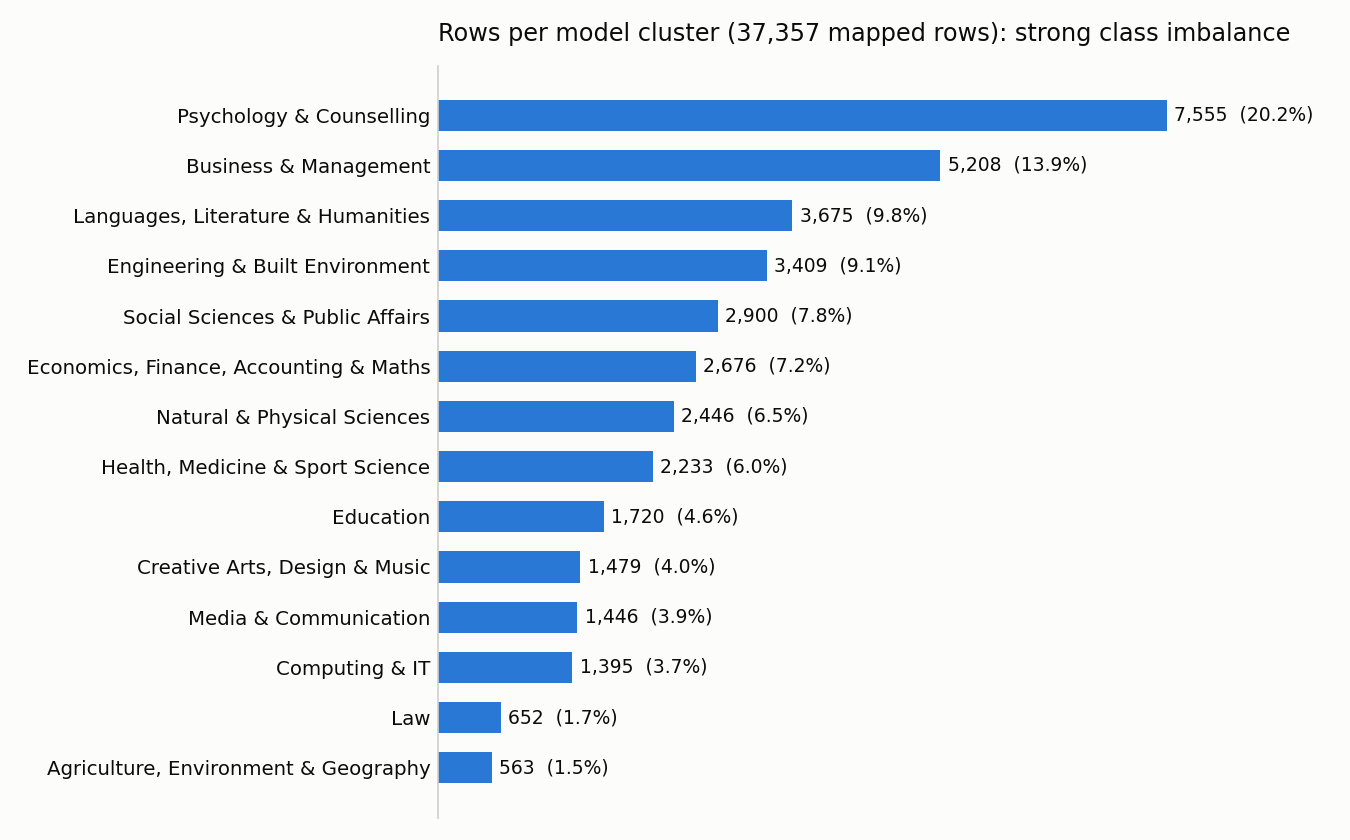

In [11]:
INK, MUTED, BLUE, SURFACE = "#0b0b0b", "#52514e", "#2a78d6", "#fcfcfb"
t = tab.sort_values("rows")
fig, ax = plt.subplots(figsize=(9, 5.6), facecolor=SURFACE); ax.set_facecolor(SURFACE)
bars = ax.barh(t.cluster_name, t.rows, color=BLUE, height=0.62)
for y, (v, p) in enumerate(zip(t.rows, t["% of mapped"])):
    ax.text(v + t.rows.max() * 0.01, y, f"{v:,}  ({p:.1f}%)", va="center", fontsize=9, color=INK)
ax.set_xlim(0, t.rows.max() * 1.22)
for s in ["top", "right", "bottom"]: ax.spines[s].set_visible(False)
ax.spines["left"].set_color("#cfcfca"); ax.tick_params(axis="y", length=0, labelsize=9.5, colors=INK); ax.set_xticks([])
ax.set_title(f"Rows per model cluster ({len(lab):,} mapped rows): strong class imbalance", loc="left", fontsize=11.5, color=INK, pad=12)
fig.tight_layout(); fig.savefig(FIG / "03_rows_per_cluster.png", dpi=150, facecolor=SURFACE); plt.close(fig)
display(Image(filename=str(FIG / "03_rows_per_cluster.png")))

## 6. Does each cluster have the RIASEC profile we would expect? (sanity check)
For each cluster we compute the **mean of each RIASEC score** (1-5). Raw means are dominated by the fact that everyone likes Social tasks more than Realistic ones, so the heatmap colours show the **difference from the overall mean**: red means this cluster scores above the average person in the sample on that scale, blue means below.
Verdicts: **matches** = every expected scale is clearly above the overall mean (at least +0.15 points, about a sixth of a standard deviation) and is among the cluster's three highest scales; **weak** = above the overall mean, but only slightly or not in the top three; **DOES NOT MATCH** = an expected scale is at or below the overall mean (for Creative Arts also if **A** is not its single highest scale). The first four clusters' expectations are yours; the rest are my own assumptions from Holland's theory and are labelled as such.

In [12]:
prof = lab.groupby("cluster_id")[SC].mean()
prof.columns = list("RIASEC")
overall = lab[SC].mean(); overall.index = list("RIASEC")
dev = prof - overall
out = prof.round(2).copy(); out.insert(0, "cluster", clusters.set_index("cluster_id").loc[prof.index, "name"])
print("Overall mean of the mapped rows:", overall.round(2).to_dict())
print("\nMean RIASEC profile per cluster (1-5):"); print(out.to_string())
print("\nDifference from overall mean:"); print(dev.round(2).to_string())

Overall mean of the mapped rows: {'R': 2.11, 'I': 3.04, 'A': 2.98, 'S': 3.4, 'E': 2.54, 'C': 2.42}

Mean RIASEC profile per cluster (1-5):
                                           cluster     R     I     A     S     E     C
cluster_id                                                                            
1                         Psychology & Counselling  1.80  3.05  2.90  3.71  2.37  2.21
2                 Social Sciences & Public Affairs  1.93  2.88  2.90  3.51  2.45  2.28
3                            Media & Communication  1.88  2.75  3.37  3.34  2.56  2.08
4                    Creative Arts, Design & Music  2.02  3.00  3.52  3.16  2.29  2.00
5               Languages, Literature & Humanities  1.97  3.02  3.31  3.35  2.39  2.17
6                                              Law  2.05  2.89  3.05  3.24  2.65  2.25
7                            Business & Management  2.17  2.73  2.90  3.38  3.00  2.78
8           Economics, Finance, Accounting & Maths  2.25  2.90  2.85  3.17  2.

In [13]:
expected = {  # cluster -> (scales expected above the overall mean, who set the expectation)
 1: ("SI", "you"), 10: ("RI", "you"), 4: ("A", "you"), 7: ("EC", "you"),
 2: ("S", "assumed"), 3: ("A", "assumed"), 5: ("A", "assumed"), 6: ("E", "assumed"), 8: ("CI", "assumed"),
 9: ("I", "assumed"), 11: ("I", "assumed"), 12: ("SI", "assumed"), 13: ("RI", "assumed"), 14: ("S", "assumed"),
}
rows = []
for cid in prof.index:
    exp, who = expected[cid]
    d = dev.loc[cid]; rank = d.rank(ascending=False)
    if any(d[s] <= 0 for s in exp) or (cid == 4 and d.idxmax() != "A"):
        verdict = "DOES NOT MATCH"
    else:
        weak = [s for s in exp if d[s] < 0.15 or rank[s] > 3]
        verdict = ("weak: " + ",".join(weak)) if weak else "matches"
    top3 = ", ".join(f"{s} ({d[s]:+.2f})" for s in d.sort_values(ascending=False).index[:3])
    exp_txt = ", ".join(f"{s} ({d[s]:+.2f})" for s in exp)
    rows.append((cid, clusters.set_index("cluster_id").loc[cid, "name"], exp_txt, who, top3, verdict))
chk = pd.DataFrame(rows, columns=["id", "cluster", "expected high (actual diff)", "expectation from", "three highest scales (diff from overall)", "check"])
print(chk.to_string(index=False))

 id                                cluster expected high (actual diff) expectation from three highest scales (diff from overall)          check
  1               Psychology & Counselling        S (+0.31), I (+0.01)              you          S (+0.31), I (+0.01), A (-0.08)        weak: I
  2       Social Sciences & Public Affairs                   S (+0.11)          assumed          S (+0.11), A (-0.09), E (-0.09)        weak: S
  3                  Media & Communication                   A (+0.38)          assumed          A (+0.38), E (+0.02), S (-0.06)        matches
  4          Creative Arts, Design & Music                   A (+0.54)              you          A (+0.54), I (-0.04), R (-0.08)        matches
  5     Languages, Literature & Humanities                   A (+0.33)          assumed          A (+0.33), I (-0.03), S (-0.05)        matches
  6                                    Law                   E (+0.11)          assumed          E (+0.11), A (+0.07), R (-0.06)        

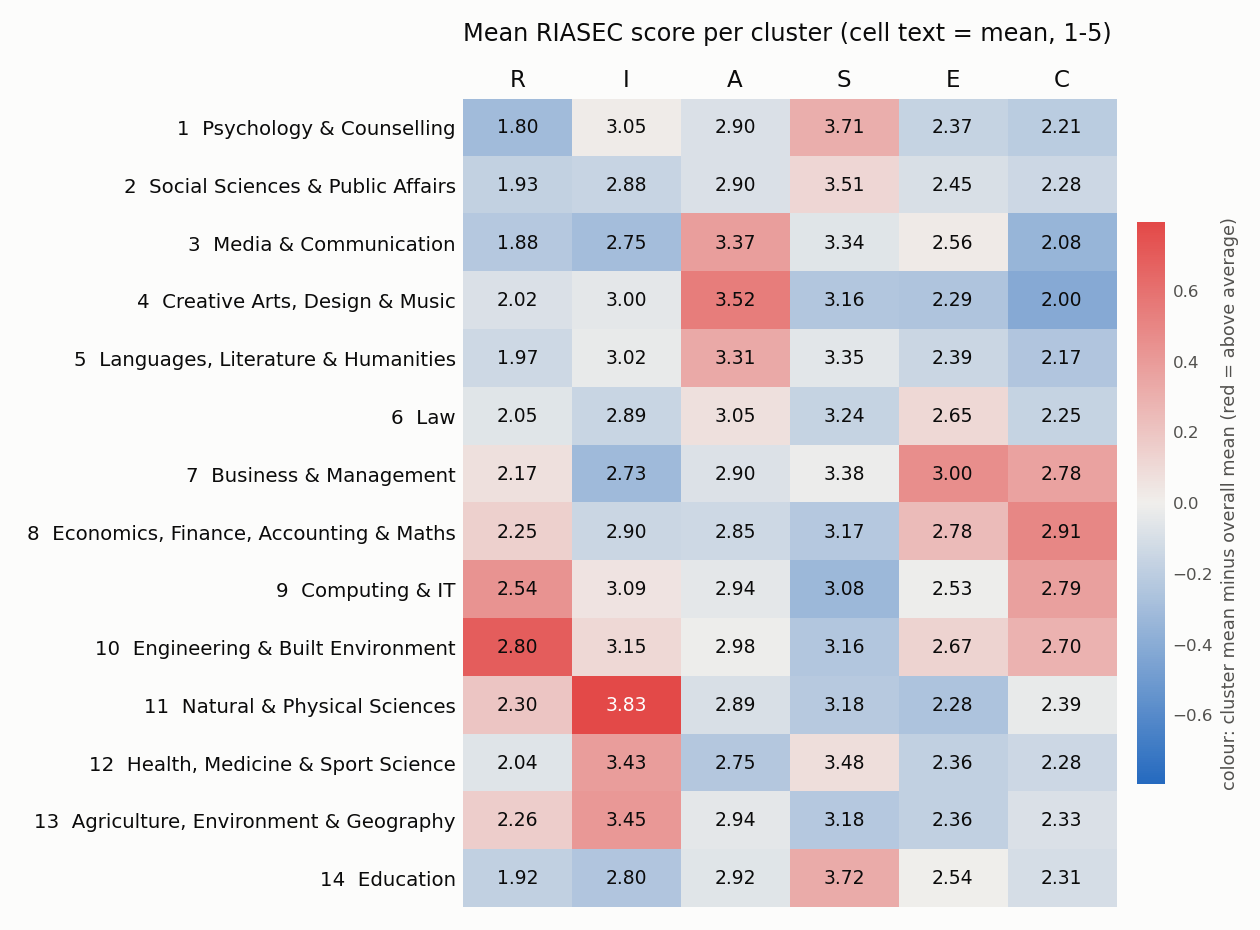

In [14]:
cmap = LinearSegmentedColormap.from_list("div", ["#256abf", "#f0efec", "#e34948"])
vmax = float(np.abs(dev.values).max())
names = clusters.set_index("cluster_id").loc[prof.index, "name"].tolist()
fig, ax = plt.subplots(figsize=(8.4, 6.2), facecolor=SURFACE); ax.set_facecolor(SURFACE)
im = ax.imshow(dev.values, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")
for i in range(dev.shape[0]):
    for j in range(dev.shape[1]):
        rgba = cmap((dev.values[i, j] + vmax) / (2 * vmax))
        lum = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
        ax.text(j, i, f"{prof.values[i, j]:.2f}", ha="center", va="center", fontsize=9, color=("#ffffff" if lum < 0.45 else INK))
ax.set_xticks(range(6)); ax.set_xticklabels(list("RIASEC"), fontsize=11, color=INK); ax.xaxis.tick_top()
ax.set_yticks(range(len(names))); ax.set_yticklabels([f"{c}  {n}" for c, n in zip(prof.index, names)], fontsize=9.5, color=INK)
ax.tick_params(length=0)
for s in ax.spines.values(): s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03); cb.outline.set_visible(False); cb.ax.tick_params(labelsize=8, colors=MUTED, length=0)
cb.set_label("colour: cluster mean minus overall mean (red = above average)", fontsize=8.5, color=MUTED)
ax.set_title("Mean RIASEC score per cluster (cell text = mean, 1-5)", loc="left", fontsize=11.5, color=INK, pad=28)
fig.tight_layout(); fig.savefig(FIG / "03_riasec_profile_heatmap.png", dpi=150, facecolor=SURFACE); plt.close(fig)
display(Image(filename=str(FIG / "03_riasec_profile_heatmap.png")))

## 7. Baselines: what does "always guess the most common cluster" score?
A model is only useful if it beats these. **Top-1** = always predict the single largest cluster. **Top-3** = always return the three largest clusters (the same three for everyone); the answer counts as right if the true cluster is among them. We show both for all mapped rows and for the test-eligible rows only.

In [15]:
def baselines(d):
    vc = d.cluster_id.value_counts()
    return vc.index[0], vc.iloc[0] / len(d), vc.index[:3].tolist(), vc.iloc[:3].sum() / len(d), len(d)
nm = clusters.set_index("cluster_id")["name"]
for label, d in [("all mapped rows", lab), ("test-eligible rows only", lab[lab.test_eligible])]:
    c1, a1, c3, a3, n_ = baselines(d)
    print(f"{label} (n={n_:,}): top-1 = always '{nm[c1]}' -> {a1:.1%} | top-3 = always {[nm[c] for c in c3]} -> {a3:.1%}")
print("\nFor reference, picking 1 of 14 clusters uniformly at random: top-1 =", f"{1/14:.1%}", "| top-3 =", f"{3/14:.1%}")

all mapped rows (n=37,357): top-1 = always 'Psychology & Counselling' -> 20.2% | top-3 = always ['Psychology & Counselling', 'Business & Management', 'Languages, Literature & Humanities'] -> 44.0%
test-eligible rows only (n=30,942): top-1 = always 'Psychology & Counselling' -> 20.0% | top-3 = always ['Psychology & Counselling', 'Business & Management', 'Languages, Literature & Humanities'] -> 43.6%

For reference, picking 1 of 14 clusters uniformly at random: top-1 = 7.1% | top-3 = 21.4%


## 8. Review lists
**8a.** Every hand mapping marked `confident = no`, largest first, so each judgement call can be checked or overruled (edit `config/major_to_cluster.csv` and rerun).
**8b.** The 30 largest keyword matches (by rows), so you can check that the tail rules do what you intended.

In [16]:
rv = manual_df[manual_df.confident == "n"].merge(counts[["major_norm", "count"]], on="major_norm")
rv["cluster"] = rv.cluster_id.map(lambda c: "" if c == "" else f"{int(c)} {nm[int(c)]}")
print(f"{len(rv)} hand mappings marked confident = no ({int(rv['count'].sum()):,} rows):")
print(rv.sort_values("count", ascending=False)[["major_norm", "count", "cluster", "note"]].to_string(index=False))

52 hand mappings marked confident = no (1,302 rows):
                          major_norm  count                                  cluster                                                                                 note
                             science    221           11 Natural & Physical Sciences                                     Vague, but you listed "science" under cluster 11
                              design    171          4 Creative Arts, Design & Music                   Listed under cluster 4, but could also be web or industrial design
                              health     57      12 Health, Medicine & Sport Science                                       Broad; you listed "health (sciences)" under 12
                      administration     49                  7 Business & Management           You listed "administration" under 7, but it could be public administration
                   human development     41       2 Social Sciences & Public Affairs       Child/

In [17]:
kw = lab[lab.method_group.isin(["keyword", "keyword-multi"])]
print(f"keyword-mapped rows: {len(kw):,}, distinct strings: {kw.major_norm.nunique():,}")
k30 = kw.groupby(["major_norm", "method", "cluster_id"]).size().reset_index(name="rows").sort_values("rows", ascending=False).head(30)
k30["cluster"] = k30.cluster_id.map(lambda c: f"{c} {nm[c]}")
print(k30[["major_norm", "rows", "method", "cluster"]].to_string(index=False))
print("\nWhich rules carry the most keyword rows:")
print(kw.method.str.replace("keyword-multi:", "multi:").str.replace("keyword:", "").value_counts().head(15).to_string())

keyword-mapped rows: 3,984, distinct strings: 2,105
                          major_norm  rows                 method                                  cluster
                         programming    10      keyword:computing                         9 Computing & IT
                     early childhood    10      keyword:education                             14 Education
                              acting    10       keyword:creative          4 Creative Arts, Design & Music
                      art and design    10   keyword-multi:manual          4 Creative Arts, Design & Music
                            pedagogy    10      keyword:education                             14 Education
                  mining engineering    10       keyword:engineer       10 Engineering & Built Environment
                   social psychology    10          keyword:psych               1 Psychology & Counselling
                           optometry    10         keyword:health      12 Health, Medicine &

## 9. Save outputs (to `processed/` only)
`riasec_labelled.csv` keeps the clean rows that received a cluster, plus `cluster_id`, `cluster_name` and `mapping_method`. `major_mapping_full.csv` lists every distinct normalised major with its result, including the unmapped ones and the reason.

In [18]:
keep = [c for c in clean.columns] + ["cluster_id", "cluster_name", "method"]
labelled = lab[keep].rename(columns={"method": "mapping_method"}).sort_values("row_id").reset_index(drop=True)
labelled.to_csv(PROC / "riasec_labelled.csv", index=False, encoding="utf-8")

# One line per normalised major. If the raw spellings of one normalised string map differently (separators such as "/"
# are lost in the normalised text), we keep the most common outcome and flag it with n_outcomes > 1.
oc = (df.assign(cluster_id=df.cluster_id.astype("Int64"))
        .groupby(["major_norm", "cluster_id", "method", "reason_final"], dropna=False).size().reset_index(name="n"))
tot = oc.groupby("major_norm")["n"].sum().rename("rows")
n_out = oc.groupby("major_norm").size().rename("n_outcomes")
best = oc.sort_values("n", ascending=False).drop_duplicates("major_norm")
full = (best.merge(tot, on="major_norm").merge(n_out, on="major_norm")
            [["major_norm", "rows", "cluster_id", "method", "reason_final", "n_outcomes"]]
            .rename(columns={"reason_final": "unmapped_reason"}).sort_values(["rows", "major_norm"], ascending=[False, True]))
full.to_csv(PROC / "major_mapping_full.csv", index=False, encoding="utf-8")

chk2 = pd.read_csv(PROC / "riasec_labelled.csv", keep_default_na=False)
print("riasec_labelled.csv:", chk2.shape, "| rows with a cluster:", int((chk2.cluster_id != "").sum()), "| clusters:", sorted(chk2.cluster_id.unique()))
print("major_mapping_full.csv:", len(full), "rows")
print("riasec_clean.csv unchanged:", hashlib.sha256((PROC / "riasec_clean.csv").read_bytes()).hexdigest() == sha_before)

riasec_labelled.csv: (37357, 66) | rows with a cluster: 37357 | clusters: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
major_mapping_full.csv: 5551 rows
riasec_clean.csv unchanged: True
